In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Imports
import numpy as np
import pandas as pd
import io
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

In [2]:
# Load data
from google.colab import files
uploaded = files.upload()

# NOTE: Replace 'P1G2.csv' with your actual dataset file path
data = pd.read_csv(io.BytesIO(uploaded['P1G2.csv']))

# Scale the data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(data)

Saving P1G2.csv to P1G2.csv


In [3]:
# --- Model 1: Isolation Forest ---
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_forest.fit(X_scaled)
iso_preds = iso_forest.predict(X_scaled)
data['Iso_Anomaly'] = np.where(iso_preds == 1, 0, 1)  # 1 = anomaly, 0 = normal

# --- Model 2: Local Outlier Factor (LOF) ---
# novelty=True is used here for consistency in prediction logic
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1, novelty=True)
lof.fit(X_scaled)
lof_preds = lof.predict(X_scaled)
data['LOF_Anomaly'] = np.where(lof_preds == 1, 0, 1)  # 1 = anomaly, 0 = normal

# --- Combined Model ---
# Logic: If either model flags it as an anomaly, it is flagged as an anomaly
data['Combined_Anomaly'] = (data['Iso_Anomaly'] + data['LOF_Anomaly']) / 2
data['Combined_Anomaly'] = np.where(data['Combined_Anomaly'] >= 0.5, 1, 0)

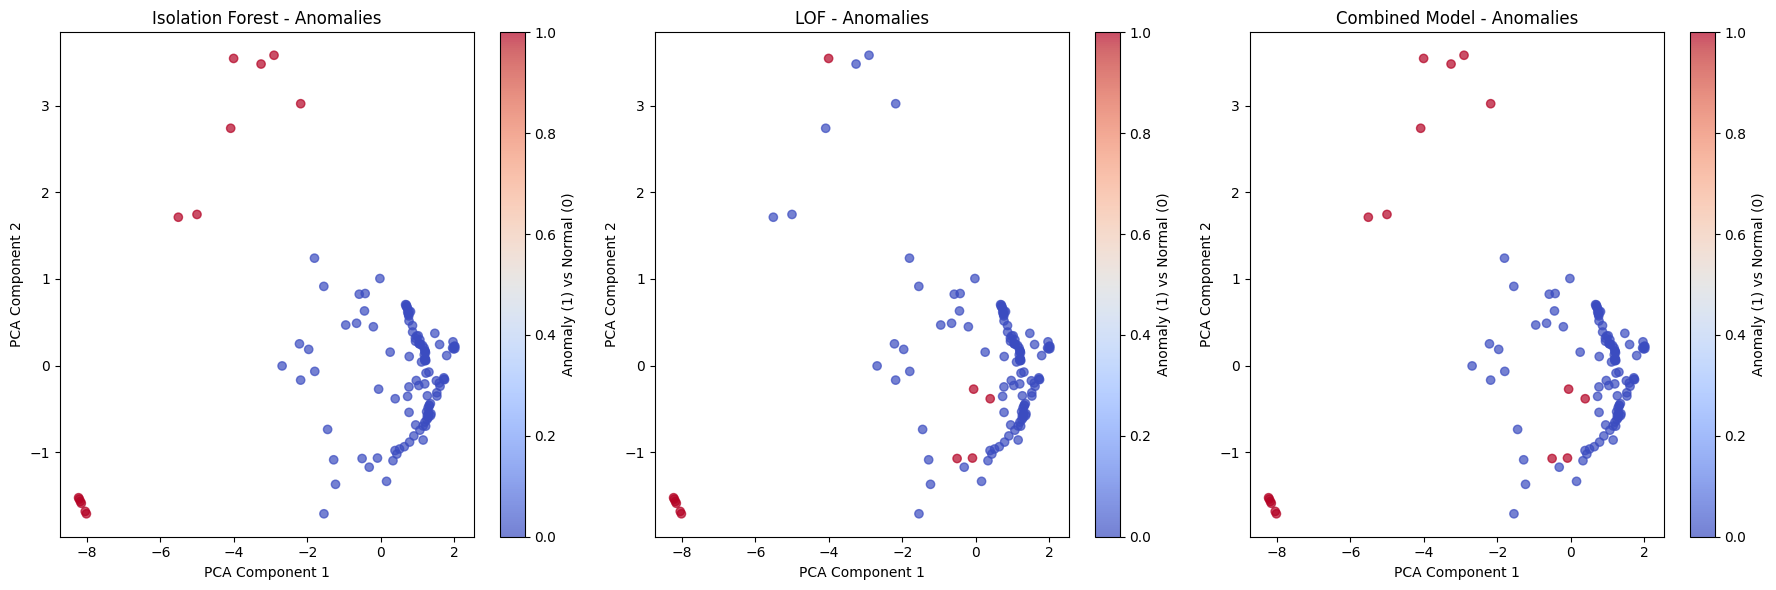

In [4]:
# --- Visualization (PCA) ---
pca = PCA(n_components=2)
data_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(18, 6))

# Plot 1: Isolation Forest
plt.subplot(1, 3, 1)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['Iso_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("Isolation Forest - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

# Plot 2: LOF
plt.subplot(1, 3, 2)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['LOF_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("LOF - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

# Plot 3: Combined
plt.subplot(1, 3, 3)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['Combined_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("Combined Model - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

plt.tight_layout()
plt.show()

In [5]:
# --- Statistical Analysis ---
iso_anomalies = data[data['Iso_Anomaly'] == 1]
lof_anomalies = data[data['LOF_Anomaly'] == 1]
combined_anomalies = data[data['Combined_Anomaly'] == 1]

print("--- Isolation Forest Statistics ---")
print(iso_anomalies.describe())

print("\n--- LOF Statistics ---")
print(lof_anomalies.describe())

print("\n--- Combined Model Statistics ---")
print(combined_anomalies.describe())

--- Isolation Forest Statistics ---
         FSR1         FSR2         FSR3         FSR4  Iso_Anomaly  \
count    13.0    13.000000    13.000000    13.000000         13.0   
mean   4095.0  1717.153846   680.307692   158.846154          1.0   
std       0.0  1720.804649   229.900118   572.727953          0.0   
min    4095.0     0.000000   446.000000     0.000000          1.0   
25%    4095.0     0.000000   479.000000     0.000000          1.0   
50%    4095.0  2192.000000   647.000000     0.000000          1.0   
75%    4095.0  3422.000000   811.000000     0.000000          1.0   
max    4095.0  3812.000000  1168.000000  2065.000000          1.0   

       LOF_Anomaly  Combined_Anomaly  
count    13.000000              13.0  
mean      0.538462               1.0  
std       0.518875               0.0  
min       0.000000               1.0  
25%       0.000000               1.0  
50%       1.000000               1.0  
75%       1.000000               1.0  
max       1.000000            

In [6]:
# --- Overlap Analysis ---
iso_set = set(iso_anomalies.index)
lof_set = set(lof_anomalies.index)
combined_set = set(combined_anomalies.index)

overlap_iso_lof = len(iso_set.intersection(lof_set))
overlap_iso_combined = len(iso_set.intersection(combined_set))
overlap_lof_combined = len(lof_set.intersection(combined_set))

print("\n--- Overlap Analysis ---")
print(f"Overlap between Isolation Forest and LOF anomalies: {overlap_iso_lof}")
print(f"Overlap between Isolation Forest and Combined anomalies: {overlap_iso_combined}")
print(f"Overlap between LOF and Combined anomalies: {overlap_lof_combined}")


--- Overlap Analysis ---
Overlap between Isolation Forest and LOF anomalies: 7
Overlap between Isolation Forest and Combined anomalies: 13
Overlap between LOF and Combined anomalies: 11


In [7]:
# --- Sensitivity Analysis (Isolation Forest) ---
print("\n--- Sensitivity Analysis (Isolation Forest) ---")
for contamination in [0.05, 0.1, 0.15]:
    iso_temp = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    iso_temp.fit(X_scaled)
    preds = iso_temp.predict(X_scaled)
    anomalies = np.where(preds == -1)[0]
    print(f"Isolation Forest Anomalies with contamination={contamination}: {len(anomalies)} anomalies")

# --- Sensitivity Analysis (LOF) ---
print("\n--- Sensitivity Analysis (LOF) ---")
for contamination in [0.05, 0.1, 0.15]:
    lof_temp = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof_temp.fit(X_scaled)
    preds = lof_temp.predict(X_scaled)
    anomalies = np.where(preds == -1)[0]
    print(f"LOF Anomalies with contamination={contamination}: {len(anomalies)} anomalies")

# --- Sensitivity Analysis (Combined Model) ---
print("\n--- Sensitivity Analysis (Combined Model) ---")
for contamination in [0.05, 0.1, 0.15]:
    iso_temp = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    iso_temp.fit(X_scaled)
    iso_preds = iso_temp.predict(X_scaled)

    lof_temp = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof_temp.fit(X_scaled)
    lof_preds = lof_temp.predict(X_scaled)

    combined_anomalies = np.where((iso_preds == -1) | (lof_preds == -1), 1, 0)
    print(f"Combined Model Anomalies with contamination={contamination}: {np.sum(combined_anomalies)} anomalies")


--- Sensitivity Analysis (Isolation Forest) ---
Isolation Forest Anomalies with contamination=0.05: 7 anomalies
Isolation Forest Anomalies with contamination=0.1: 13 anomalies
Isolation Forest Anomalies with contamination=0.15: 19 anomalies

--- Sensitivity Analysis (LOF) ---
LOF Anomalies with contamination=0.05: 2 anomalies
LOF Anomalies with contamination=0.1: 11 anomalies
LOF Anomalies with contamination=0.15: 13 anomalies

--- Sensitivity Analysis (Combined Model) ---
Combined Model Anomalies with contamination=0.05: 9 anomalies
Combined Model Anomalies with contamination=0.1: 17 anomalies
Combined Model Anomalies with contamination=0.15: 21 anomalies


In [8]:
# --- Consensus Model (Majority Vote) ---
print("\n--- Consensus Model (Majority Vote) ---")
contamination_levels = [0.05, 0.1, 0.15]
iso_anomalies_list = []
lof_anomalies_list = []

for contamination in contamination_levels:
    iso_temp = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    iso_temp.fit(X_scaled)
    iso_preds = iso_temp.predict(X_scaled)
    iso_anomalies_list.append(np.where(iso_preds == -1, 1, 0))

    lof_temp = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof_temp.fit(X_scaled)
    lof_preds = lof_temp.predict(X_scaled)
    lof_anomalies_list.append(np.where(lof_preds == -1, 1, 0))

iso_consensus = np.sum(iso_anomalies_list, axis=0) >= len(contamination_levels) / 2
lof_consensus = np.sum(lof_anomalies_list, axis=0) >= len(contamination_levels) / 2
combined_consensus = np.where((iso_consensus | lof_consensus), 1, 0)

print("Consensus-based Combined Model Anomalies:", np.sum(combined_consensus))


--- Consensus Model (Majority Vote) ---
Consensus-based Combined Model Anomalies: 17


In [9]:
# --- Synthetic Anomaly Injection Test ---
print("\n--- Synthetic Anomaly Injection Test ---")
# Step 1: Inject synthetic anomalies
synthetic_anomalies = data.sample(5, random_state=42).copy()
synthetic_anomalies += np.random.normal(50, 20, synthetic_anomalies.shape)

# Step 2: Append to original dataset
data_with_synthetic = pd.concat([data, synthetic_anomalies], ignore_index=True)

# Step 3: Prepare data for prediction (re-scale)
X_synthetic_scaled = scaler.transform(data_with_synthetic.drop(columns=['Iso_Anomaly', 'LOF_Anomaly', 'Combined_Anomaly']))

# Step 4: Apply models to detect anomalies in the new dataset
iso_forest_preds = iso_forest.predict(X_synthetic_scaled)
iso_synthetic_anomalies = np.where(iso_forest_preds == -1, 1, 0)

lof_preds = lof.predict(X_synthetic_scaled)
lof_synthetic_anomalies = np.where(lof_preds == -1, 1, 0)

# Step 5: Combine predictions
combined_synthetic_anomalies = np.where((iso_synthetic_anomalies + lof_synthetic_anomalies) >= 1, 1, 0)

# Step 6: Check if the synthetic anomalies (last 5 entries) are detected
print("Isolation Forest synthetic anomaly detection:", iso_synthetic_anomalies[-5:])
print("LOF synthetic anomaly detection:", lof_synthetic_anomalies[-5:])
print("Combined model synthetic anomaly detection:", combined_synthetic_anomalies[-5:])


--- Synthetic Anomaly Injection Test ---
Isolation Forest synthetic anomaly detection: [0 0 0 1 0]
LOF synthetic anomaly detection: [0 0 0 1 1]
Combined model synthetic anomaly detection: [0 0 0 1 1]
